# CSE 2600 HW 3

## Q1

**A.** 
\begin{gather*}
\log\left(\frac{p}{1 - p}\right) = \beta_0 + \beta_1 X_1 + \beta_2 X_2\\
\beta_0 = -4.2,\quad \beta_1 = 0.04,\quad \beta_2 = 0.8\\
z = \beta_0 + \beta_1 X_1 + \beta_2 X_2\\
z = -4.2 + 0.04(60) + 0.8(2)\\
z = -0.2\\
p = \frac{1}{1 + e^{-z}}\\
p = \frac{1}{1 + e^{0.2}} \approx 0.45
\end{gather*}
So the estimated probability is 0.45 or 45%.

**B.** 
\begin{gather*}
p=0.9\\
p = \frac{1}{1 + e^{-z}}\\
0.9 = \frac{1}{1 + e^{-z}}\\
1 + e^{-z} = \frac{1}{0.9}\\
1 + e^{-z} \approx 1.1111\\
e^{-z} = 0.1111\\
-z = ln(0.1111)\\
-z \approx -2.1972\\
z = 2.1972\\
2.1972 = −4.2+0.04X_1​+0.8(2)\\
2.1972 = -2.6+0.04X_1\\
4.7972 = 0.04X_1\\
X_1 = 119.93
\end{gather*}
So the applicant would need about 120 hours of practice.

**C.** 
$\beta_0$ is the intercept in the logistic regression. It represents the log-odds of admission when $X_1 = 0$ and $X_2 = 0$ (someone with 0 coding hours and 0 years of prior experience). Here, $-4.2$ is a very negative log-odds, meaning the probability of admission for such an applicant is very low. It odds would be $p = \frac{1}{1 + e^{-4.2}} \approx 0.0147$ or about $1.47\%.$

## Q2

In [2]:
from ISLP import load_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

OJ = load_data('OJ')

Train = OJ[OJ['StoreID'].isin([1, 2, 3, 4])].copy()
Test = OJ[OJ['StoreID'] == 7].copy()

#Part A, Calculate mean, standard deviation, median, minimum value, and maximum value
Train['PriceDiff'] = Train['PriceMM'] - Train['PriceCH']
train_subset = Train[['LoyalCH', 'SpecialCH', 'PriceDiff']] 
summary_stats = train_subset.agg(['mean', 'std', 'median', 'min', 'max'])
print(f"\n\033[1mA.\033[0m")
print(summary_stats)

#Part B, Calculate the correlation matrix
correlation_matrix = train_subset.corr()
print(f"\n\033[1mB.\033[0m")
print(correlation_matrix)

#Part C, Perform a logistic regression
Train['Purchase_CH'] = (Train['Purchase'] == 'CH').astype(int)
X_train = Train[['LoyalCH', 'SpecialCH', 'PriceDiff']].copy()
X_train['intercept'] = 1  
y_train = Train['Purchase_CH']
glm = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = glm.fit()
print(f"\n\033[1mC.\033[0m")
print(results.summary())



A.
         LoyalCH  SpecialCH  PriceDiff
mean    0.519988   0.046218   0.204762
std     0.313757   0.210105   0.118882
median  0.500000   0.000000   0.240000
min     0.000011   0.000000   0.000000
max     0.999947   1.000000   0.440000

B.
            LoyalCH  SpecialCH  PriceDiff
LoyalCH    1.000000   0.014230   0.013981
SpecialCH  0.014230   1.000000  -0.115511
PriceDiff  0.013981  -0.115511   1.000000

C.
                 Generalized Linear Model Regression Results                  
Dep. Variable:            Purchase_CH   No. Observations:                  714
Model:                            GLM   Df Residuals:                      710
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -310.82
Date:                Wed, 05 Nov 2025   Deviance:                       621.63
Time:                        23:3

**Cont. C.** Based on the results of the logistic regression, two of the three predictors seem to be statistically significant in predicting whether a customer purchases Citrus Hill. The variable LoyalCH has a coefficient of 6.118 with a p-value of 0.000, showing a highly significant positive effect: as loyalty increases, the probability of purchasing Citrus Hill rises sharply. Similarly, PriceDiff has a coefficient of 2.824 with a p-value of 0.001, showing that as Citrus Hill becomes cheaper relative to Minute Maid, the odds of purchase increase significantly. Whereas, SpecialCH has a coefficient near zero (-0.022) and a very high p-value (0.961), suggesting that the presence of a Citrus Hill promotion does not have a meaningful effect on purchase behavior. Therefore, LoyalCH and PriceDiff are statistically significant predictors, while SpecialCH is not.


D.
Confusion Matrix:
           Pred 1  Pred 0
Actual 1     239      35
Actual 0      27      55
Overall Accuracy: 0.826
Percent False Positives: 7.58%
Percent False Negatives: 9.83%

E.
                 Generalized Linear Model Regression Results                  
Dep. Variable:            Purchase_CH   No. Observations:                  714
Model:                            GLM   Df Residuals:                      711
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -310.82
Date:                Mon, 20 Oct 2025   Deviance:                       621.63
Time:                        02:01:40   Pearson chi2:                     736.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4006
Covariance Type:            nonrobust                                         
                 coef 

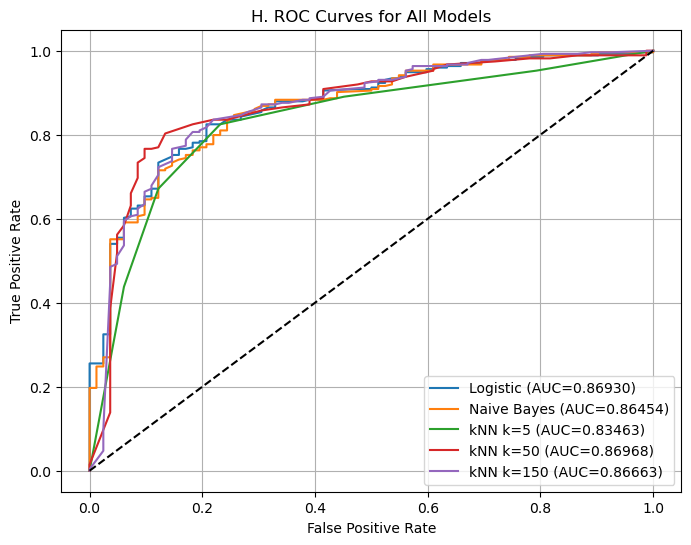

In [81]:
#Part D, compute the confusion matrix and overall fraction of correct predictions. 
Test['PriceDiff'] = Test['PriceMM'] - Test['PriceCH']
Test['Purchase_CH'] = (Test['Purchase'] == 'CH').astype(int)
X_test = Test[['LoyalCH','SpecialCH','PriceDiff']].copy()
X_test['intercept'] = 1
y_test = Test['Purchase_CH']


def predict(X, model):
    predictions_df = pd.DataFrame(model.get_prediction(X).predicted, columns=['y_hat'], index=X.index)
    return predictions_df['y_hat']
probs_train = predict(X_train, results)
probs_test = predict(X_test, results)
predictions_train = (probs_train >= 0.5).astype(int)
predictions_test = (probs_test >= 0.5).astype(int)

def confusion_matrix_metrics(y_true, y_pred):
    TP = ((y_true == 1) & (y_pred == 1)).sum()
    TN = ((y_true == 0) & (y_pred == 0)).sum()
    FP = ((y_true == 0) & (y_pred == 1)).sum()
    FN = ((y_true == 1) & (y_pred == 0)).sum()
    
    total = len(y_true)
    accuracy = (TP + TN) / total
    false_positive_pct = FP / total * 100
    false_negative_pct = FN / total * 100
    
    conf_matrix = pd.DataFrame([[TP, FN], [FP, TN]], index=['Actual 1', 'Actual 0'], columns=['Pred 1', 'Pred 0'])
    return conf_matrix, accuracy, false_positive_pct, false_negative_pct
print(f"\n\033[1mD.\033[0m")
conf_matrix, accuracy, fp_pct, fn_pct = confusion_matrix_metrics(y_test, predictions_test)
print("Confusion Matrix:\n", conf_matrix)
print(f"Overall Accuracy: {accuracy:.3f}")
print(f"Percent False Positives: {fp_pct:.2f}%")
print(f"Percent False Negatives: {fn_pct:.2f}%")

#Part E, Logistic regression with only significant predictors
X_train_sig = Train[['LoyalCH', 'PriceDiff']].copy()
X_test_sig = Test[['LoyalCH', 'PriceDiff']].copy()
X_train_sig['intercept'] = 1
X_test_sig['intercept'] = 1
y_train = Train['Purchase_CH']

glm_sig = sm.GLM(y_train, X_train_sig, family=sm.families.Binomial())
results_sig = glm_sig.fit()
print(f"\n\033[1mE.\033[0m")
print(results_sig.summary())

probs_test_sig = predict(X_test_sig, results_sig)
predictions_test_sig = (probs_test_sig >= 0.5).astype(int)

conf_matrix_sig, accuracy_sig, fp_pct_sig, fn_pct_sig = confusion_matrix_metrics(y_test, predictions_test_sig)

print("Confusion Matrix (Significant Predictors Only):\n", conf_matrix_sig)
print(f"Overall Accuracy: {accuracy_sig:.3f}")
print(f"Percent False Positives: {fp_pct_sig:.2f}%")
print(f"Percent False Negatives: {fn_pct_sig:.2f}%")

#Part F, Naive Bayes with only the significant predictors
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_sig, y_train)

predictions_test_nb = nb_model.predict(X_test_sig)

conf_matrix_nb, accuracy_nb, fp_pct_nb, fn_pct_nb = confusion_matrix_metrics(y_test, predictions_test_nb)

print(f"\n\033[1mF.\033[0m Naive Bayes (Significant Predictors Only)")
print("Confusion Matrix:\n", conf_matrix_nb)
print(f"Overall Accuracy: {accuracy_nb:.3f}")
print(f"Percent False Positives: {fp_pct_nb:.2f}%")
print(f"Percent False Negatives: {fn_pct_nb:.2f}%")

#Part G, Build three k-Nearest Neighbors models on the Train data
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sig)
X_test_scaled = scaler.transform(X_test_sig)

k_values = [5, 50, 150]
knn_models = {}
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    knn_models[k] = knn

knn50 = knn_models[50]
predictions_test_knn50 = knn50.predict(X_test_scaled)

conf_matrix_knn50, accuracy_knn50, fp_pct_knn50, fn_pct_knn50 = confusion_matrix_metrics(y_test, predictions_test_knn50)

print(f"\n\033[1mG.\033[0m kNN (k=50, Significant Predictors Only)")
print("Confusion Matrix:\n", conf_matrix_knn50)
print(f"Overall Accuracy: {accuracy_knn50:.3f}")
print(f"Percent False Positives: {fp_pct_knn50:.2f}%")
print(f"Percent False Negatives: {fn_pct_knn50:.2f}%")

#Part H, ROC curve for each of the five models
from sklearn.metrics import roc_curve, roc_auc_score

probs_logistic = predict(X_test_sig, results_sig)
probs_nb = nb_model.predict_proba(X_test_sig)[:, 1]
probs_knn = {}
for k, model in knn_models.items():
    probs_knn[k] = model.predict_proba(X_test_scaled)[:, 1]
plt.figure(figsize=(8, 6))

# Logistic regression
fpr, tpr, _ = roc_curve(y_test, probs_logistic)
auc_log = roc_auc_score(y_test, probs_logistic)
plt.plot(fpr, tpr, label=f'Logistic (AUC={auc_log:.5f})')

# Naive Bayes
fpr, tpr, _ = roc_curve(y_test, probs_nb)
auc_nb = roc_auc_score(y_test, probs_nb)
plt.plot(fpr, tpr, label=f'Naive Bayes (AUC={auc_nb:.5f})')

# kNN models
for k in [5, 50, 150]:
    fpr, tpr, _ = roc_curve(y_test, probs_knn[k])
    auc_knn = roc_auc_score(y_test, probs_knn[k])
    plt.plot(fpr, tpr, label=f'kNN k={k} (AUC={auc_knn:.5f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('H. ROC Curves for All Models')
plt.legend()
plt.grid(True)
plt.show()



**Cont. H.**
Among the five models, kNN with k = 50 yields the highest AUC of 0.86968, indicating it has the best overall ability to distinguish between classes on the Test data. Logistic regression is very close, with an AUC of 0.86930, while Naive Bayes and the other kNN models have slightly lower AUCs (0.86454 for Naive Bayes, 0.83463 for k=5, and 0.86663 for k=150).

## Q3

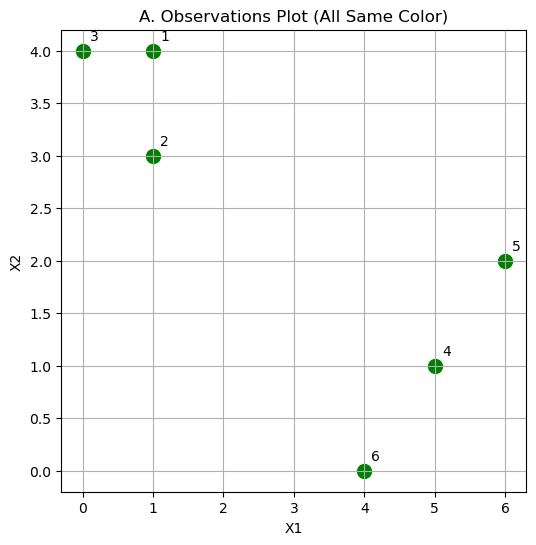


B. Cluster Labels for Each Observation
   Obs  X1  X2  Cluster
0    1   1   4        1
1    2   1   3        2
2    3   0   4        1
3    4   5   1        1
4    5   6   2        1
5    6   4   0        2

C. Centroids for Each Cluster
          X1    X2
Cluster           
1        3.0  2.75
2        2.5  1.50

D. Cluster Assignment Based on Closest Centroid
   Obs  X1  X2  Cluster_Assigned
0    1   1   4                 1
1    2   1   3                 1
2    3   0   4                 1
3    4   5   1                 2
4    5   6   2                 1
5    6   4   0                 2

E. Iteration 1 Results
   Obs  X1  X2  Cluster
0    1   1   4        1
1    2   1   3        1
2    3   0   4        1
3    4   5   1        2
4    5   6   2        2
5    6   4   0        2
Centroids:
           X1    X2
Cluster           
1        2.0  3.25
2        4.5  0.50 


E. Iteration 2 Results
   Obs  X1  X2  Cluster
0    1   1   4        1
1    2   1   3        1
2    3   0   4        1
3  

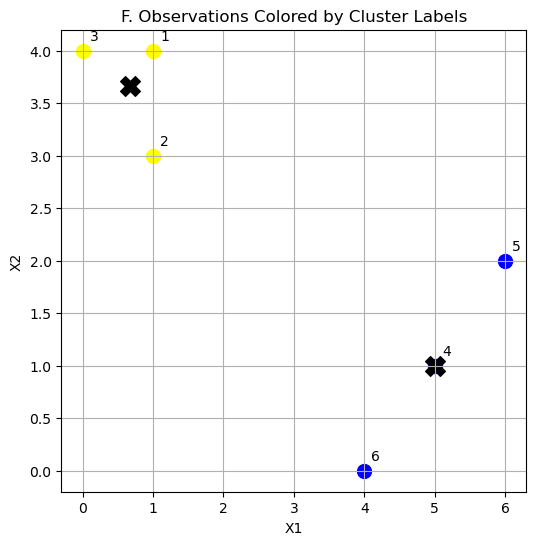

In [82]:
#Part A, Ploting the observations
data = pd.DataFrame({
    'Obs': [1, 2, 3, 4, 5, 6],
    'X1': [1, 1, 0, 5, 6, 4],
    'X2': [4, 3, 4, 1, 2, 0]
})

plt.figure(figsize=(6,6))
plt.scatter(data['X1'], data['X2'], color='green', s=100)
for i, row in data.iterrows():
    plt.text(row['X1'] + 0.1, row['X2'] + 0.1, str(row['Obs']))  # label points

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('A. Observations Plot (All Same Color)')
plt.grid(True)
plt.show()

#Part B, Cluster labels for each observation
np.random.seed(42)
data['Cluster'] = np.random.choice([1, 2], size=len(data))
print(f"\n\033[1mB.\033[0m Cluster Labels for Each Observation")
print(data[['Obs', 'X1', 'X2', 'Cluster']])

#Part C, Compute the centroid for each cluster.
centroids = data.groupby('Cluster')[['X1', 'X2']].mean()
print(f"\n\033[1mC.\033[0m Centroids for Each Cluster")
print(centroids)

#Part D, Assign the centroid observation to which it is closest
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))

def assign_clusters(df, centroids):
    new_clusters = []
    for _, row in df.iterrows():
        distances = centroids.apply(lambda c: euclidean_distance(row[['X1','X2']], c), axis=1)
        new_clusters.append(distances.idxmin())  # closest centroid's cluster
    df['Cluster_Assigned'] = new_clusters
    return df
data = assign_clusters(data, centroids)
print(f"\n\033[1mD.\033[0m Cluster Assignment Based on Closest Centroid")
print(data[['Obs','X1','X2','Cluster_Assigned']])

#Part E, Repeat (c) and (d)
data['Cluster'] = data['Cluster_Assigned']
changed = True
iteration = 0
while changed:
    iteration += 1
    centroids = data.groupby('Cluster')[['X1','X2']].mean()
    old_clusters = data['Cluster'].copy()
    data = assign_clusters(data, centroids)
    data['Cluster'] = data['Cluster_Assigned']
    changed = not all(old_clusters == data['Cluster'])
    
    print(f"\n\033[1mE.\033[0m Iteration {iteration} Results")
    print(data[['Obs','X1','X2','Cluster']])
    print("Centroids:\n", centroids, "\n")

#Part F, Plot observations colored by final cluster
plt.figure(figsize=(6,6))
colors = {1: 'yellow', 2: 'blue'}
for _, row in data.iterrows():
    plt.scatter(row['X1'], row['X2'], color=colors[row['Cluster']], s=100)
    plt.text(row['X1'] + 0.1, row['X2'] + 0.1, str(row['Obs']))

for cluster_id, centroid in centroids.iterrows():
    plt.scatter(centroid['X1'], centroid['X2'], color='black', s=200, marker='X', label=f'Centroid {cluster_id}')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('F. Observations Colored by Cluster Labels')
plt.grid(True)
plt.show()

## Q4

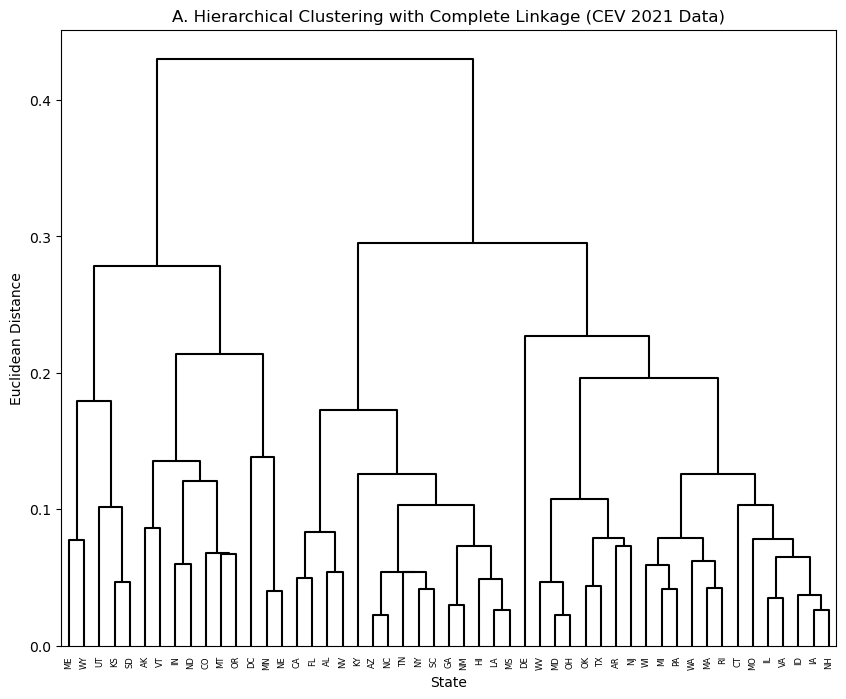

   State  Cluster3
0     WY         1
1     ME         1
2     MT         1
3     NE         1
4     KS         1
5     IN         1
6     OR         1
7     DC         1
8     ND         1
9     SD         1
10    CO         1
11    UT         1
12    VT         1
13    AK         1
14    MN         1
15    MS         2
16    NC         2
17    NY         2
18    NM         2
19    NV         2
20    TN         2
21    SC         2
22    AL         2
23    LA         2
24    KY         2
25    AZ         2
26    CA         2
27    HI         2
28    GA         2
29    FL         2
30    MA         3
31    WV         3
32    WA         3
33    VA         3
34    AR         3
35    TX         3
36    CT         3
37    DE         3
38    RI         3
39    OK         3
40    MI         3
41    OH         3
42    ID         3
43    IL         3
44    NJ         3
45    NH         3
46    IA         3
47    WI         3
48    MD         3
49    PA         3
50    MO         3


In [85]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from ISLP.cluster import compute_linkage 
from scipy.cluster.hierarchy import dendrogram, fcluster

#Setting up the data set 
cev_2021 = pd.read_csv('../data/CEV2021.csv')

#Part A, Clustering states using hierarchical clustering
cev_numeric = cev_2021.select_dtypes(include='number')

hc_comp = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='complete')
hc_comp.fit(cev_numeric)
linkage_comp = compute_linkage(hc_comp)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=cev_2021['State'].values,
           color_threshold=-np.inf,
           above_threshold_color='black')
ax.set_title("A. Hierarchical Clustering with Complete Linkage (CEV 2021 Data)")
ax.set_xlabel("State")
ax.set_ylabel("Euclidean Distance")
plt.show()

#Part B, Cut the dendrogram to create 3 clusters
cluster_labels = fcluster(linkage_comp, t=3, criterion='maxclust')
cev_2021['Cluster3'] = cluster_labels
print(cev_2021[['State', 'Cluster3']].sort_values('Cluster3').reset_index(drop=True))



**Cont. B.** 
Using linkage hierarchical clustering and Euclidean distance, the states group into three major clusters.<br>
Cluster 1: WY, ME, MT, NE, KS, IN, OR, DC, ND, SD, CO, UT, VT, AK, MN<br>
Cluster 2: MS, NC, NY, NM, NV, TN, SC, AL, LA, KY, AZ, CA, HI, GA, FL<br>
Cluster 3: MA, WV, WA, VA, AR, TX, CT, DE, RI, OK, MI, OH, ID, IL, NJ, NH, IA, WI, MD, PA, MO<br>

In [86]:
#Part C, Cut the dendrogram to create 4 clusters
cluster_labels_4 = fcluster(linkage_comp, t=4, criterion='maxclust')
cev_2021['Cluster4'] = cluster_labels_4
print(cev_2021[['State', 'Cluster4']].sort_values('Cluster4').reset_index(drop=True))

   State  Cluster4
0     WY         1
1     ME         1
2     UT         1
3     KS         1
4     SD         1
5     MT         2
6     NE         2
7     IN         2
8     OR         2
9     ND         2
10    CO         2
11    VT         2
12    AK         2
13    DC         2
14    MN         2
15    MS         3
16    NC         3
17    NY         3
18    NM         3
19    SC         3
20    NV         3
21    TN         3
22    AL         3
23    LA         3
24    KY         3
25    AZ         3
26    CA         3
27    HI         3
28    GA         3
29    FL         3
30    MA         4
31    WV         4
32    WA         4
33    VA         4
34    AR         4
35    TX         4
36    CT         4
37    DE         4
38    RI         4
39    OK         4
40    MI         4
41    OH         4
42    ID         4
43    IL         4
44    NJ         4
45    NH         4
46    IA         4
47    WI         4
48    MD         4
49    PA         4
50    MO         4


**Cont. C.** 
Using linkage hierarchical clustering and Euclidean distance, the states group into four major clusters.<br>
Cluster 1: WY, ME, UT, KS, SD<br>
Cluster 2: MT, NE, IN, OR, ND, CO, VT, AK, DC, MN<br>
Cluster 3: MS, NC, NY, NM, SC, NV, TN, AL, LA, KY, AZ, CA, HI, GA, FL<br>
Cluster 4: MA, WV, WA, VA, AR, TX, CT, DE, RI, OK, MI, OH, ID, IL, NJ, NH, IA, WI, MD, PA, MO

In [88]:
#Part D, K-means clustering to obtain new clusters of states
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(cev_numeric)
cev_2021['KMeans_Cluster3'] = kmeans.labels_ + 1
print(cev_2021[['State', 'KMeans_Cluster3']].sort_values('KMeans_Cluster3').reset_index(drop=True))


   State  KMeans_Cluster3
0     MO                1
1     WI                1
2     MI                1
3     MA                1
4     PA                1
5     KS                1
6     IA                1
7     IN                1
8     ID                1
9     RI                1
10    IL                1
11    SD                1
12    WA                1
13    VA                1
14    UT                1
15    NH                1
16    DE                1
17    CT                1
18    TX                2
19    OK                2
20    SC                2
21    NC                2
22    NJ                2
23    TN                2
24    NY                2
25    NM                2
26    WV                2
27    OH                2
28    AL                2
29    HI                2
30    MS                2
31    AZ                2
32    MD                2
33    AR                2
34    LA                2
35    CA                2
36    KY                2
37    NV    

**Cont. D.**
Using K-means clustering, the states group into 3 major clusters.<br>
Cluster 1: MO, WI, MI, MA, PA, KS, IA, IN, ID, RI, IL, SD, WA, VA, UT, NH, DE, CT<br>
Cluster 2: TX, OK, SC, NC, NJ, TN, NY, NM, WV, OH, AL, HI, MS, AZ, MD, AR, LA, CA, KY, NV, GA, FL<br>
Cluster 3: AK, VT, CO, NE, OR, ME, ND, MN, MT, DC, WY

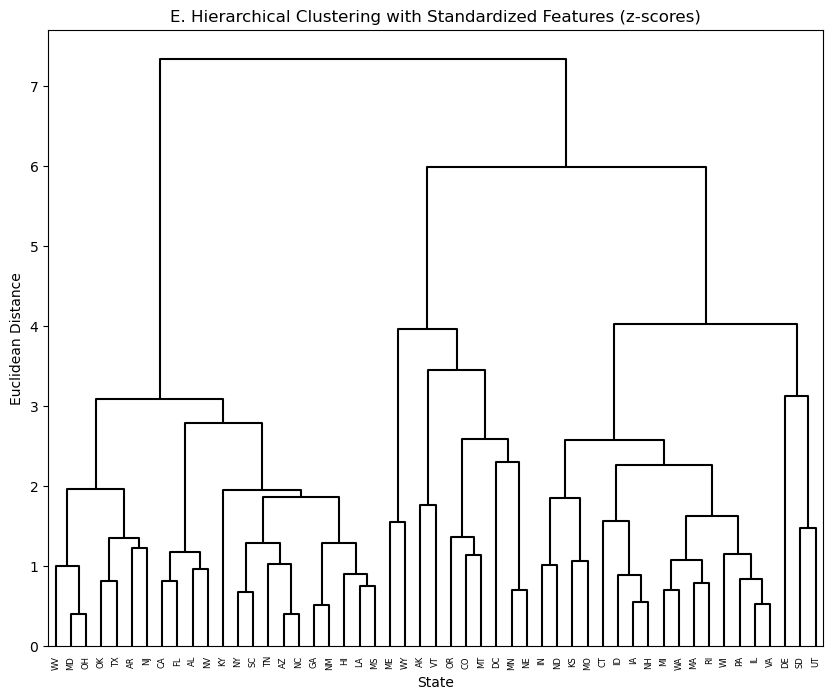

   State  Cluster3_Scaled
0     AL                1
1     MD                1
2     NM                1
3     LA                1
4     KY                1
5     NY                1
6     NC                1
7     OH                1
8     OK                1
9     MS                1
10    NJ                1
11    HI                1
12    FL                1
13    SC                1
14    TN                1
15    TX                1
16    CA                1
17    AR                1
18    AZ                1
19    WV                1
20    GA                1
21    NV                1
22    NE                2
23    OR                2
24    VT                2
25    MT                2
26    WY                2
27    MN                2
28    AK                2
29    ME                2
30    CO                2
31    DC                2
32    WA                3
33    VA                3
34    UT                3
35    CT                3
36    DE                3
37    SD    

In [89]:
# Part E: Repeat Part A with standardized features (z-scores)
scaler = StandardScaler()
cev_scaled = scaler.fit_transform(cev_numeric)

hc_comp_scaled = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='complete')
hc_comp_scaled.fit(cev_scaled)
linkage_comp_scaled = compute_linkage(hc_comp_scaled)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
dendrogram(linkage_comp_scaled,
           ax=ax,
           leaf_rotation=90,
           labels=cev_2021['State'].values,
           color_threshold=-np.inf,
           above_threshold_color='black')
ax.set_title("E. Hierarchical Clustering with Standardized Features (z-scores)")
ax.set_xlabel("State")
ax.set_ylabel("Euclidean Distance")
plt.show()

# Part F: Cut the standardized dendrogram to create 3 clusters
cluster_labels_scaled = fcluster(linkage_comp_scaled, t=3, criterion='maxclust')
cev_2021['Cluster3_Scaled'] = cluster_labels_scaled
print(cev_2021[['State', 'Cluster3_Scaled']].sort_values('Cluster3_Scaled').reset_index(drop=True))



**Cont. F.** 
Using linkage hierarchical clustering and Euclidean distance with standardized features, the states group into three major clusters.<br>
Cluster 1: AL, MD, NM, LA, KY, NY, NC, OH, OK, MS, NJ, HI, FL, SC, TN, TX, CA, AR, AZ, WV, GA, NV<br>
Cluster 2: NE, OR, VT, MT, WY, MN, AK, ME, CO, DC<br>
Cluster 3: WA, VA, UT, CT, DE, SD, RI, PA, ID, IL, IN, ND, IA, KS, MA, NH, MI, WI, MO<br>

In [90]:
# Part G: K-means clustering with K=3 on standardized data
kmeans_scaled = KMeans(n_clusters=3, random_state=42)
kmeans_scaled.fit(cev_scaled)
cev_2021['KMeans_Cluster3_Scaled'] = kmeans_scaled.labels_ + 1
print(cev_2021[['State', 'KMeans_Cluster3_Scaled']].sort_values('KMeans_Cluster3_Scaled').reset_index(drop=True))

   State  KMeans_Cluster3_Scaled
0     WY                       1
1     ME                       1
2     DC                       1
3     VT                       1
4     TX                       2
5     TN                       2
6     SC                       2
7     OK                       2
8     OH                       2
9     WV                       2
10    NC                       2
11    NY                       2
12    NM                       2
13    NJ                       2
14    NV                       2
15    MS                       2
16    MD                       2
17    LA                       2
18    AL                       2
19    FL                       2
20    GA                       2
21    HI                       2
22    AZ                       2
23    AR                       2
24    CA                       2
25    KY                       2
26    KS                       3
27    PA                       3
28    RI                       3
29    SD  

**Cont. G.**
Using K-means clustering on standardized data , the states group into 3 major clusters.<br>
Cluster 1: WY, ME, DC, VT<br>
Cluster 2: TX, TN, SC, OK, OH, WV, NC, NY, NM, NJ, NV, MS, MD, LA, AL, FL, GA, HI, AZ, AR, CA, KY<br>
Cluster 3: KS, PA, RI, SD, UT, VA, WA, AK, CO, OR, ND, DE, ID, NH, IL, NE, MT, WI, IN, MN, MI, MA, IA, CT, MO

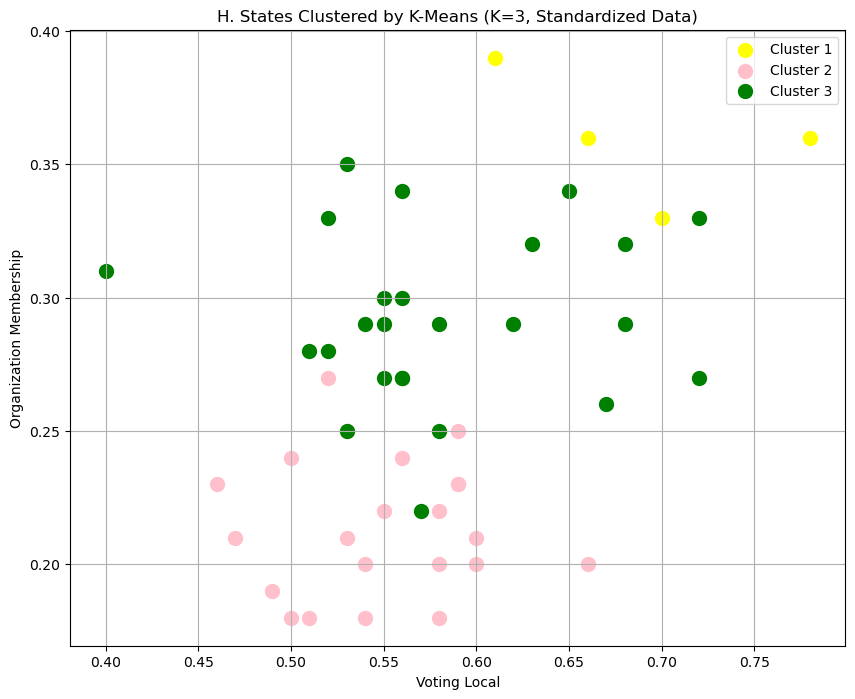

In [96]:
# Part H: Scatter plot colored by K-means clusters
plt.figure(figsize=(10, 8))
colors = {1: 'yellow', 2: 'pink', 3: 'green'}

for cluster in [1, 2, 3]:
    cluster_data = cev_2021[cev_2021['KMeans_Cluster3_Scaled'] == cluster]
    plt.scatter(cluster_data['Voting_Local'], 
                cluster_data['Organizational_Membership'],
                c=colors[cluster], 
                label=f'Cluster {cluster}',
                s=100)

plt.xlabel('Voting Local')
plt.ylabel('Organization Membership')
plt.title('H. States Clustered by K-Means (K=3, Standardized Data)')
plt.legend()
plt.grid(True)
plt.show()